In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load preprocessing_train.parquet
df_train = pd.read_parquet('preprocessing_train.parquet')

# Load preprocessing_test.parquet
df_test = pd.read_parquet('preprocessing_test.parquet')

print("preprocessing_train.parquet head:")
display(df_train.head())

print("preprocessing_test.parquet head:")
display(df_test.head())

preprocessing_train.parquet head:


,federalPolicyFee,hfiaaSurcharge,policyCost,policyCount,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,totalInsurancePremiumOfThePolicy,reserveFundAssessment,originalConstructionDate,originalNBDate,...,policyTerminationDate,elevatedBuildingIndicator,postFIRMConstructionIndicator,primaryResidenceIndicator,mandatoryPurchaseFlag,ratedFloodZone_X,ratedFloodZone_AE,coord_x,coord_y,coord_z
0,-1.095671,-0.647591,346,-0.096999,0.287760,0.648721,-0.544076,-0.538643,0.919092,0.518824,...,-1.625521,True,False,True,False,False,False,1.108277,1.292637,1.544664
1,-0.164325,-0.647591,295,-0.096999,-0.840678,-1.781678,-0.656198,-0.538643,1.036053,0.736138,...,-1.594654,False,False,False,False,False,True,0.250586,0.828012,1.463924
2,-1.095671,-0.647591,148,-0.096999,-0.858404,0.201146,-0.855267,-0.538643,0.482422,0.730122,...,-1.576934,False,False,True,False,True,False,0.600415,-0.596844,-0.660945
3,-0.164325,-0.647591,413,-0.096999,-0.704245,-1.781678,-0.476393,-0.538643,0.943158,0.892399,...,-1.663820,False,False,True,False,False,True,-0.788061,0.038554,0.431639
4,-1.095671,-0.647591,348,-0.096999,0.287760,0.648721,-0.541045,-0.538643,-0.756333,0.369141,...,-1.472899,False,True,True,False,True,False,-2.486378,1.213791,0.378731


preprocessing_test.parquet head:


,federalPolicyFee,hfiaaSurcharge,policyCost,policyCount,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,totalInsurancePremiumOfThePolicy,reserveFundAssessment,originalConstructionDate,originalNBDate,...,policyTerminationDate,elevatedBuildingIndicator,postFIRMConstructionIndicator,primaryResidenceIndicator,mandatoryPurchaseFlag,ratedFloodZone_X,ratedFloodZone_AE,coord_x,coord_y,coord_z
0,-0.164325,-0.647591,2007,-0.096999,0.287760,-1.781678,1.415972,-0.538643,0.712322,0.407308,...,-1.561500,False,False,False,False,False,True,0.674881,-0.865654,-1.212934
1,-0.164325,-0.647591,323,-0.096999,0.131956,0.368379,-0.612845,-0.538643,-0.874349,0.804047,...,-1.591224,False,True,True,False,False,True,0.881876,0.230503,0.431639
2,-0.164325,-0.647591,978,-0.096999,0.287760,0.648721,0.293340,-0.538643,-0.004410,0.554386,...,-1.507768,True,True,False,False,False,True,0.939092,0.471319,0.710547
3,-0.164325,-0.647591,359,-0.096999,0.287760,-1.781678,-0.557742,-0.538643,-1.055935,0.439512,...,-1.638097,True,True,True,False,False,True,0.801729,0.102064,0.307892
4,-1.095671,-0.647591,297,-0.096999,0.287760,0.115560,-0.619012,-0.538643,0.753242,0.398288,...,-1.540350,False,False,False,False,True,False,0.985632,1.151590,1.480121


Multicollinearity may be an issue, as `policyCost` is the sum of `totalInsurancePremiumOfThePolicy`, `reserveFundAssessment`, `federalPolicyFee`, and `hfiaaSurcharge`. I should get rid of these columns.

In [2]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Drop columns that cause multicollinearity/leakage
leakage_cols = ['totalInsurancePremiumOfThePolicy', 'reserveFundAssessment', 'federalPolicyFee', 'hfiaaSurcharge']

# Prepare features and target
# We check for existence in case they were already dropped or named differently
X = df_train.drop(columns=['policyCost'] + [c for c in leakage_cols if c in df_train.columns])
y = df_train['policyCost']

# Prepare test set
X_test = df_test.drop(columns=['policyCost'] + [c for c in leakage_cols if c in df_test.columns])
y_test = df_test['policyCost']

# Split training data into train/val for model selection
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training features: 16
Training samples: 284517
Validation samples: 71130
Test samples: 355573


In [3]:
# 1. Linear Regression
linear_reg = LinearRegression().fit(X_train, y_train)

In [4]:
# 2. Ridge Regression
ridge = RandomizedSearchCV(Ridge(), {'alpha': [0.1, 1.0, 10.0]}, n_iter=3, cv=3, random_state=42).fit(X_train, y_train)

In [5]:
# 3. Lasso Regression
lasso = RandomizedSearchCV(Lasso(max_iter=2000), {'alpha': [0.001, 0.01, 0.1]}, n_iter=3, cv=3, random_state=42).fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.860e+10, tolerance: 7.535e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.052e+11, tolerance: 7.233e+07
  model = cd_fast.enet_coordinate_descent(


In [6]:
# 4. XGBoost
from xgboost import XGBRegressor
xgb = RandomizedSearchCV(XGBRegressor(objective='reg:squarederror', random_state=42),
                         {'n_estimators': [100, 200], 'max_depth': [3, 6], 'learning_rate': [0.01, 0.1]},
                         n_iter=4, cv=3, n_jobs=-1, random_state=42).fit(X_train, y_train)

In [7]:
from sklearn.ensemble import RandomForestRegressor

# 5. Random Forest (Optimized for speed)
# Using a smaller n_iter and max_samples to speed up the process
rf = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                        {'n_estimators': [50, 100], 'max_depth': [10, 20], 'max_samples': [0.1, 0.3]},
                        n_iter=3, cv=3, random_state=42).fit(X_train, y_train)

In [8]:
from sklearn.neural_network import MLPRegressor

# 6. Neural Network (MLP)
# early_stopping=True is key to preventing unnecessary computation
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=100,
                   early_stopping=True, random_state=42).fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

# Updated models dictionary
models = {
    'Linear': linear_reg,
    'Ridge': ridge.best_estimator_,
    'Lasso': lasso.best_estimator_,
    'XGBoost': xgb.best_estimator_,
    'RandomForest': rf.best_estimator_,
    'NeuralNet': mlp
}

val_results = []
for name, model in models.items():
    val_preds = model.predict(X_val)
    mse = mean_squared_error(y_val, val_preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, val_preds)
    r2 = r2_score(y_val, val_preds)

    val_results.append({
        'Model': name,
        'Val MSE': mse,
        'Val RMSE': rmse,
        'Val MAE': mae,
        'Val R2': r2
    })

summary_df = pd.DataFrame(val_results).sort_values(by='Val MSE')
display(summary_df)

,Model,Val MSE,Val RMSE,Val MAE,Val R2
4,RandomForest,1.568207e+06,1252.280537,406.806190,0.537560
5,NeuralNet,1.677622e+06,1295.230299,456.224806,0.505295
3,XGBoost,1.720594e+06,1311.714193,422.122101,0.492623
2,Lasso,2.348467e+06,1532.470806,624.041078,0.307474
1,Ridge,2.348475e+06,1532.473339,624.179497,0.307471
0,Linear,2.348492e+06,1532.479106,624.205835,0.307466


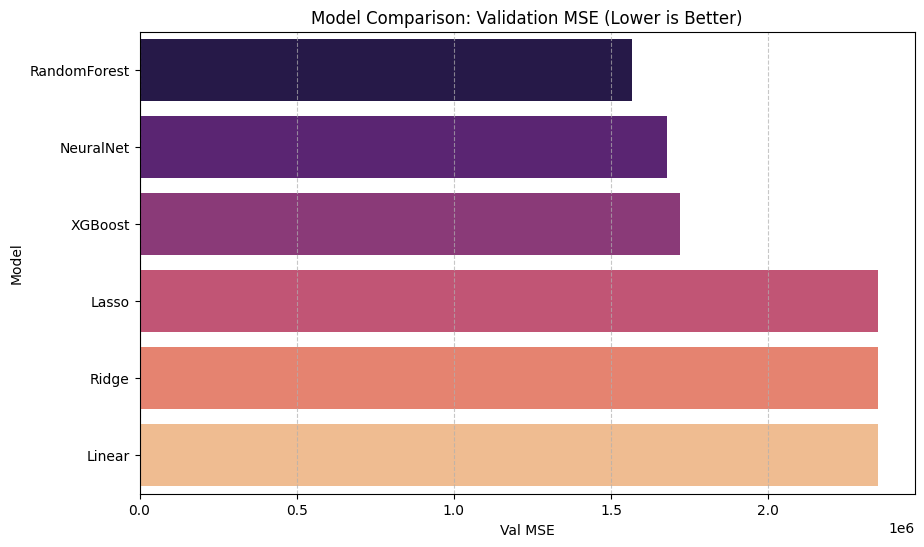

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Validation Results
plt.figure(figsize=(10, 6))
sns.barplot(data=summary_df, x='Val MSE', y='Model', hue='Model', palette='magma', legend=False)
plt.title('Model Comparison: Validation MSE (Lower is Better)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error

# Final Evaluation on Test Set for the overall winner
best_model_name = summary_df.iloc[0]['Model']
best_model = models[best_model_name]

test_preds = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, test_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

print(f"--- FINAL PERFORMANCE REPORT ---")
print(f"Winning Model: {best_model_name}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R2: {test_r2:.4f}")

--- FINAL PERFORMANCE REPORT ---
Winning Model: RandomForest
Test MSE: 1779859.7177
Test RMSE: 1334.1138
Test MAE: 409.1102
Test R2: 0.5058


Displaying importance for winner: RandomForest


/tmp/ipykernel_27362/4157373804.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


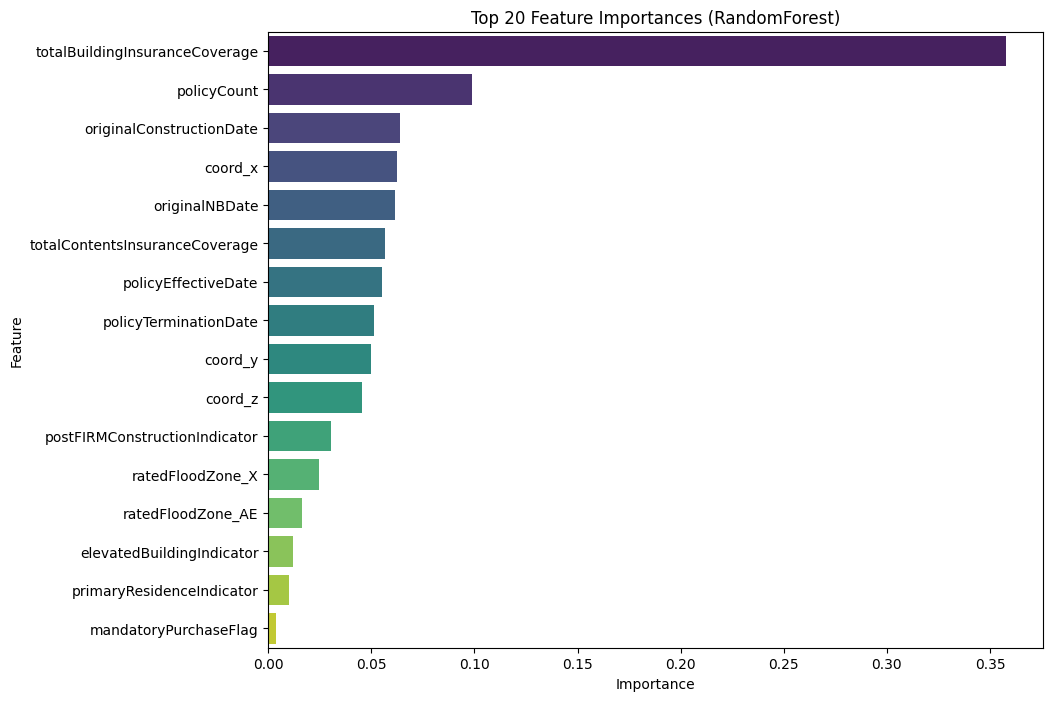

In [12]:
# Visualize Feature Importance for the best model
best_model_name = summary_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Displaying importance for winner: {best_model_name}")

if best_model_name in ['Ridge', 'Lasso']:
    importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': best_model.coef_})
elif hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': best_model.feature_importances_})
else:
    importance_df = None
    print(f"Feature importance not directly available for {best_model_name}.")

if importance_df is not None:
    importance_df['Abs_Importance'] = importance_df['Importance'].abs()
    importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 20 Feature Importances ({best_model_name})')
    plt.show()